In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import RemoveMessage

In [2]:
load_dotenv()

True

In [3]:
model =   ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")


In [4]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [6]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [7]:
graph = builder.compile(checkpointer=InMemorySaver())

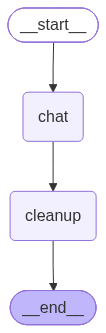

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "t1"}}

In [10]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Suman"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='e3192184-d1d4-4671-9b80-e8fdc04095b5'),
  AIMessage(content=[{'type': 'text', 'text': 'If **LangGraph** is the "engine" for building complex, looping agent systems, **LangChain** is the "toolbox" that provides the individual parts.\n\nAt its simplest: **LangChain is a framework designed to simplify the creation of applications using Large Language Models (LLMs).**\n\nBefore LangChain existed, if you wanted to talk to an LLM (like GPT-4), you had to write a lot of boilerplate code to handle API calls, manage prompts, and parse the text coming back. LangChain standardized this process.\n\n---\n\n### The "Core Pillars" of LangChain\nLangChain is organized into several key components that act as building blocks for your AI app:\n\n#### 1. Model I/O (The Interface)\nLangChain provides a unified interface for almost any LLM (OpenAI, Anthropic, Google Gemini, Ollama, etc.). \n*   **Prompt T

In [11]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8


Since there is 14 message generated so which is greater than 10. So first 6 messages ie 3 conversation is deleted. 